## RED

### RamdomForest

#### No Feature Engineering + RandomForest

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [3]:
red_wine_df = pd.read_csv('./datasets/winequality-red.csv', sep=';')
df_red = red_wine_df.copy()
x = df_red.drop('quality', axis=1)
y = df_red['quality']

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

rf_model_1 = RandomForestClassifier(
    n_estimators=150,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

rf_model_1.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [4]:
y_pred = rf_model_1.predict(X_test)

print(f"🔥 모델 정확도: {accuracy_score(y_test, y_pred):.2%}")
print("\n=== 상세 성적표 ===")
print(classification_report(y_test, y_pred, zero_division=0))

🔥 모델 정확도: 64.38%

=== 상세 성적표 ===
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.69      0.78      0.73       130
           6       0.62      0.61      0.62       132
           7       0.57      0.57      0.57        42
           8       0.00      0.00      0.00         5

    accuracy                           0.64       320
   macro avg       0.31      0.33      0.32       320
weighted avg       0.61      0.64      0.63       320



It only make sense in wine dataset that's quality is between 5-6. The reason why this happened is 'quantity of the dataset'.

/tmp/ipykernel_97717/1212613849.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=x.columns[indices], palette='magma')


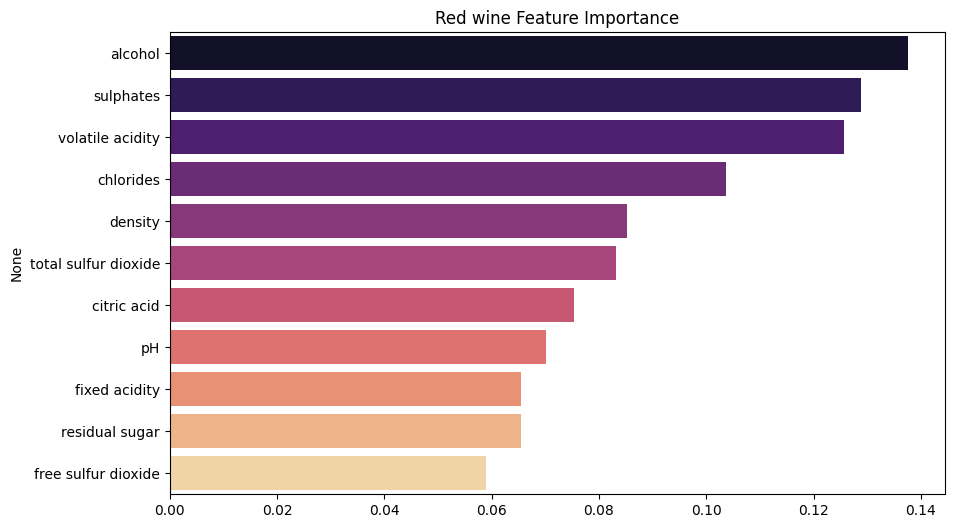

In [5]:
importances = rf_model_1.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=x.columns[indices], palette='magma')
plt.title('Red wine Feature Importance')
plt.show()

#### Feature engineering + RandomForest

In [6]:
def create_new_features(df):
    df_new = df.copy()

    # Feature 1 : 활성 이산화황 비율
    # 0으로 나누는 것을 방지하기 위해 0.000001 같은 아주 작은 수를 더해줌
    df_new['so2_ratio'] = df_new['free sulfur dioxide'] / (df_new['total sulfur dioxide'] + 0.000001)

    # Feature 2 : 당도-산도 비율
    df_new['sugar_acidity_ratio'] = df_new['residual sugar'] / (df_new['fixed acidity'] + 0.000001)

    # Feature 3: 알코올 대비 밀도 (바디감 지표)
    df_new['alcohol_density'] = df_new['alcohol'] * df_new['density']
    
    return df_new


In [8]:
red_wine_df = pd.read_csv('./datasets/winequality-red.csv', sep=';')

red_wine_df = create_new_features(red_wine_df)

X = red_wine_df.drop('quality', axis=1)
y = red_wine_df['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
rf_new = RandomForestClassifier(
    n_estimators=150, 
    max_depth=10, 
    class_weight='balanced', 
    random_state=42
)

rf_new.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

🔥 피처 엔지니어링 후 정확도: 65.62%

=== 상세 성적표 ===
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.71      0.77      0.74       130
           6       0.63      0.66      0.64       132
           7       0.57      0.55      0.56        42
           8       0.00      0.00      0.00         5

    accuracy                           0.66       320
   macro avg       0.32      0.33      0.32       320
weighted avg       0.62      0.66      0.64       320



/tmp/ipykernel_97717/2974456666.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances_new[indices_new], y=X.columns[indices_new], palette="coolwarm")


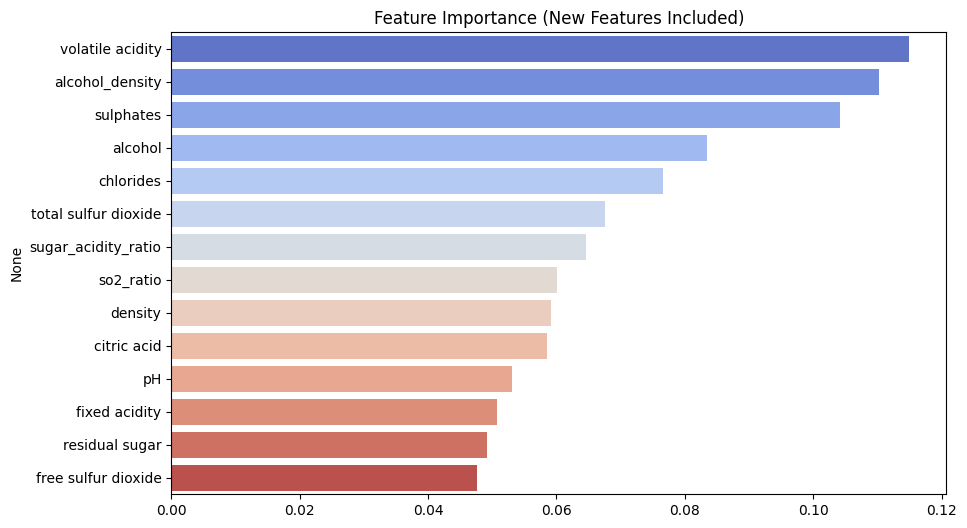

In [14]:
y_pred_new = rf_new.predict(X_test)
print(f"🔥 피처 엔지니어링 후 정확도: {accuracy_score(y_test, y_pred_new):.2%}")
print("\n=== 상세 성적표 ===")
print(classification_report(y_test, y_pred_new, zero_division=0))

# 5. 새로운 변수가 얼마나 중요한지 확인 (Top 10)
importances_new = rf_new.feature_importances_
indices_new = np.argsort(importances_new)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances_new[indices_new], y=X.columns[indices_new], palette="coolwarm")
plt.title("Feature Importance (New Features Included)")
plt.show()

Model has a little better performace than before. But still the Problem of Imabanaced data doesn't solved.

#### SMOTE (No Feature Engineering) + RandomForest

In [15]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

In [16]:
red_wine_df = pd.read_csv('./datasets/winequality-red.csv', sep=';')

df = red_wine_df.copy()

X = df.drop('quality', axis=1)
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

smote = SMOTE(k_neighbors=1, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 4. 뻥튀기 결과 확인
print("=== SMOTE 적용 전 데이터 개수 ===")
print(y_train.value_counts().sort_index())
print("\n=== SMOTE 적용 후 데이터 개수 (모두 똑같이 맞춰짐) ===")
print(y_train_res.value_counts().sort_index())

# 5. 모델 학습
# 데이터 개수를 SMOTE로 맞췄으니 class_weight 옵션은 뺍니다.
rf_smote = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42)
rf_smote.fit(X_train_res, y_train_res)

# 6. 결과 확인
y_pred = rf_smote.predict(X_test)

print(f"\n🔥 SMOTE 적용 후 정확도: {accuracy_score(y_test, y_pred):.2%}")
print("\n=== 상세 성적표 ===")
print(classification_report(y_test, y_pred, zero_division=0))

=== SMOTE 적용 전 데이터 개수 ===
quality
3      9
4     43
5    551
6    506
7    157
8     13
Name: count, dtype: int64

=== SMOTE 적용 후 데이터 개수 (모두 똑같이 맞춰짐) ===
quality
3    551
4    551
5    551
6    551
7    551
8    551
Name: count, dtype: int64

🔥 SMOTE 적용 후 정확도: 65.94%

=== 상세 성적표 ===
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.18      0.20      0.19        10
           5       0.74      0.73      0.73       130
           6       0.67      0.65      0.66       132
           7       0.57      0.64      0.61        42
           8       0.25      0.20      0.22         5

    accuracy                           0.66       320
   macro avg       0.40      0.40      0.40       320
weighted avg       0.66      0.66      0.66       320



#### SMOTE (Feature Engineering) + RandomForest

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import SMOTE

# -------------------------------------------------------
# 1. Feature Engineering (모델에게 고급 힌트 주기)
# -------------------------------------------------------
def create_new_features(df):
    df_new = df.copy()
    
    # Feature A: 활성 이산화황 비율 (방부제 효율성)
    df_new['so2_ratio'] = df_new['free sulfur dioxide'] / (df_new['total sulfur dioxide'] + 0.000001)
    
    # Feature B: 당도-산도 밸런스 (맛의 조화)
    df_new['sugar_acidity_ratio'] = df_new['residual sugar'] / (df_new['fixed acidity'] + 0.000001)
    
    # Feature C: 알코올-밀도 관계 (바디감의 척도)
    df_new['alcohol_density'] = df_new['alcohol'] * df_new['density']
    
    return df_new

In [19]:
red_wine_df = pd.read_csv('./datasets/winequality-red.csv', sep=';')

df_red = red_wine_df.copy()

df_engineered = create_new_features(df_red)

X = df_engineered.drop('quality', axis=1)
y = df_engineered['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
smote = SMOTE(k_neighbors=1, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"SMOTE 적용 전 훈련 데이터: {len(y_train)}")
print(f"SMOTE 적용 후 훈련 데이터: {len(y_train_res)}")

SMOTE 적용 전 훈련 데이터: 1279
SMOTE 적용 후 훈련 데이터: 3306


In [21]:
rf_final = RandomForestClassifier(
    n_estimators=300,   # 나무 개수를 좀 더 늘려서(300) 신중하게 판단
    max_depth=20,       # 깊이도 조금 더 깊게 허용
    random_state=42
)
rf_final.fit(X_train_res, y_train_res)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y


🔥 [피처 엔지니어링 + SMOTE] 최종 정확도: 66.88%

=== 상세 성적표 ===
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.08      0.10      0.09        10
           5       0.75      0.75      0.75       130
           6       0.68      0.67      0.68       132
           7       0.57      0.62      0.59        42
           8       0.50      0.20      0.29         5

    accuracy                           0.67       320
   macro avg       0.43      0.39      0.40       320
weighted avg       0.67      0.67      0.67       320



/tmp/ipykernel_97717/1370140666.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=X.columns[indices], palette="viridis")


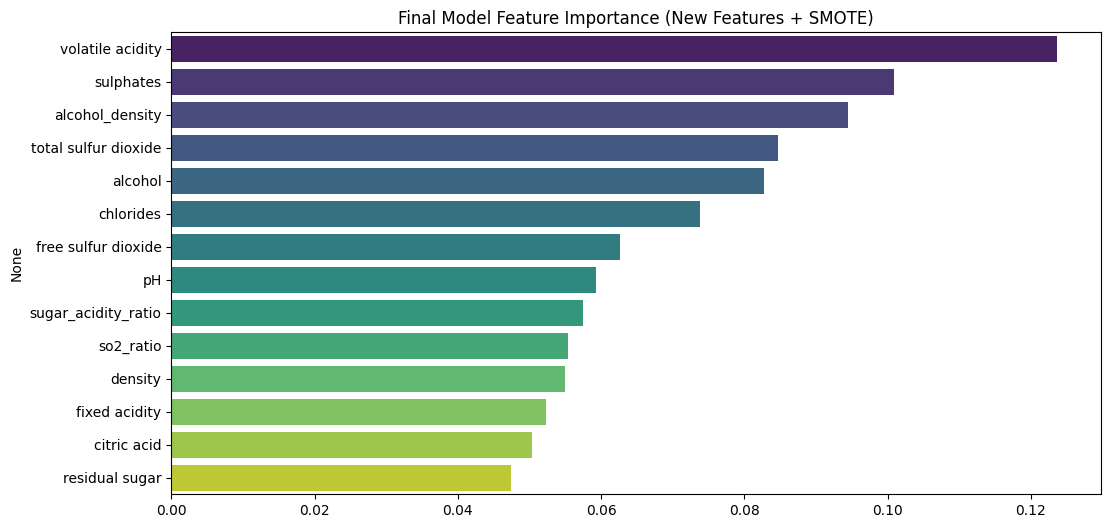

In [22]:
y_pred_final = rf_final.predict(X_test)

print(f"\n🔥 [피처 엔지니어링 + SMOTE] 최종 정확도: {accuracy_score(y_test, y_pred_final):.2%}")
print("\n=== 상세 성적표 ===")
print(classification_report(y_test, y_pred_final, zero_division=0))

# -------------------------------------------------------
# 6. 최종 중요 변수 시각화
# -------------------------------------------------------
importances = rf_final.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
sns.barplot(x=importances[indices], y=X.columns[indices], palette="viridis")
plt.title("Final Model Feature Importance (New Features + SMOTE)")
plt.show()

### Ensemble

#### SMOTE (Feature Engineering) + Ensemble (lightGBM + XGBoost)

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 모델링 라이브러리
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.ensemble import VotingClassifier
from imblearn.over_sampling import SMOTE

# Boosting 모델
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [24]:
red_wine_df = pd.read_csv('./datasets/winequality-red.csv', sep=';')
df_red = red_wine_df.copy()

df_red['so2_ratio'] = df_red['free sulfur dioxide'] / (df_red['total sulfur dioxide'] + 0.000001)
df_red['sugar_acidity_ratio'] = df_red['residual sugar'] / (df_red['fixed acidity'] + 0.000001)
df_red['alcohol_density'] = df_red['alcohol'] * df_red['density']

X = df_red.drop('quality', axis=1)
y = df_red['quality']

In [25]:
# XGBoost/LightGBM은 타겟값이 0부터 시작해야 오류가 안 납니다.
# 예: 품질 3, 4, 5, 6, 7, 8 -> 0, 1, 2, 3, 4, 5 로 변환
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# SMOTE 적용 (k_neighbors=1)
smote = SMOTE(k_neighbors=1, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"SMOTE 적용 후 학습 데이터 크기: {len(y_train_res)}")

SMOTE 적용 후 학습 데이터 크기: 3306


In [27]:
# XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=10,
    random_state=42,
    eval_metric='mlogloss'
)

# LightGBM
lgbm_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=10,
    random_state=42,
    verbose=-1 # 경고 메시지 끄기
)

# 5. 앙상블 (Voting Ensemble)
# -------------------------------------------------------
# 두 모델의 예측 확률을 평균 내어 투표하는 방식 (Soft Voting)
voting_model = VotingClassifier(
    estimators=[('xgb', xgb_model), ('lgbm', lgbm_model)],
    voting='soft'
)

# 앙상블 모델 학습
print("앙상블 모델 학습 중... ⏳")
voting_model.fit(X_train_res, y_train_res)

앙상블 모델 학습 중... ⏳


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('xgb', ...), ('lgbm', ...)]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None



🔥 [XGBoost + LightGBM 앙상블] 최종 정확도: 67.50%

=== 상세 성적표 ===
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.12      0.10      0.11        10
           5       0.76      0.74      0.75       130
           6       0.67      0.71      0.69       132
           7       0.59      0.57      0.58        42
           8       0.25      0.20      0.22         5

    accuracy                           0.68       320
   macro avg       0.40      0.39      0.39       320
weighted avg       0.67      0.68      0.67       320



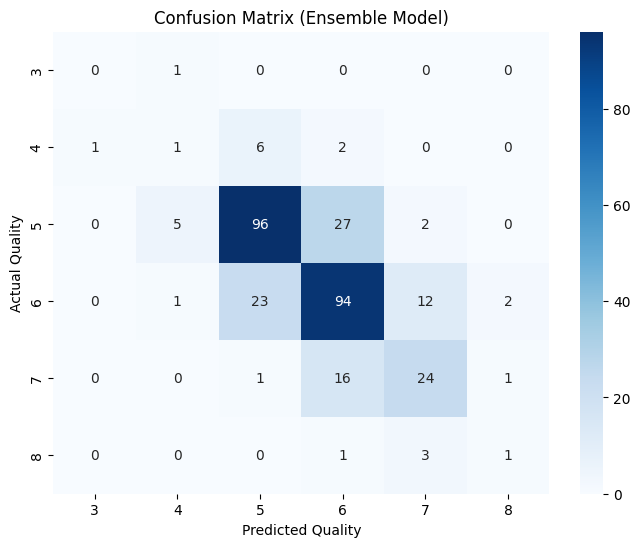

In [28]:
y_pred = voting_model.predict(X_test)

# 인코딩된 라벨을 다시 원래 점수(3~8점)로 복구
y_test_original = le.inverse_transform(y_test)
y_pred_original = le.inverse_transform(y_pred)

print(f"\n🔥 [XGBoost + LightGBM 앙상블] 최종 정확도: {accuracy_score(y_test_original, y_pred_original):.2%}")
print("\n=== 상세 성적표 ===")
print(classification_report(y_test_original, y_pred_original, zero_division=0))

# Confusion Matrix 시각화
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_original, y_pred_original)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix (Ensemble Model)')
plt.xlabel('Predicted Quality')
plt.ylabel('Actual Quality')
plt.show()

## White

### RandomForest

#### No Feature Engineering + RandomForest

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [3]:
white_wine_df = pd.read_csv('./datasets/winequality-white.csv', sep=';')
df_white = white_wine_df.copy()
x = df_white.drop('quality', axis=1)
y = df_white['quality']

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

rf_model_1 = RandomForestClassifier(
    n_estimators=150,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

rf_model_1.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [4]:
y_pred = rf_model_1.predict(X_test)

print(f"🔥 모델 정확도: {accuracy_score(y_test, y_pred):.2%}")
print("\n=== 상세 성적표 ===")
print(classification_report(y_test, y_pred, zero_division=0))

🔥 모델 정확도: 57.35%

=== 상세 성적표 ===
              precision    recall  f1-score   support

           3       0.50      0.20      0.29         5
           4       0.43      0.48      0.45        25
           5       0.56      0.69      0.62       291
           6       0.63      0.46      0.53       432
           7       0.52      0.69      0.59       192
           8       0.73      0.54      0.62        35

    accuracy                           0.57       980
   macro avg       0.56      0.51      0.52       980
weighted avg       0.59      0.57      0.57       980



/tmp/ipykernel_21050/1212613849.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=x.columns[indices], palette='magma')


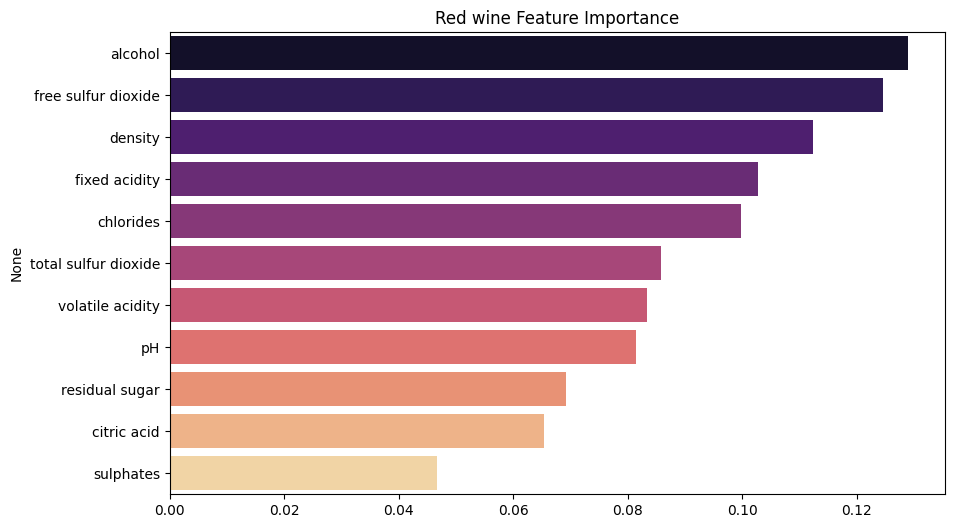

In [5]:
importances = rf_model_1.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=x.columns[indices], palette='magma')
plt.title('Red wine Feature Importance')
plt.show()

#### Feature Engineering + RandomForest

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [2]:
def create_new_features(df):
    df_new = df.copy()

    df_new['so2_ratio'] = df_new['free sulfur dioxide'] / (df_new['total sulfur dioxide'] + 0.000001)
    df_new['sugar_acidity_ratio'] = df_new['residual sugar'] / (df_new['fixed acidity'] + 0.000001)

    # Feature 3: 알코올 대비 밀도 (바디감 지표)
    df_new['alcohol_density'] = df_new['alcohol'] * df_new['density']
    
    return df_new


In [3]:
white_wine_df = pd.read_csv('./datasets/winequality-white.csv', sep=';')

white_wine_df = create_new_features(white_wine_df)

X = white_wine_df.drop('quality', axis=1)
y = white_wine_df['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
rf_model_1 = RandomForestClassifier(
    n_estimators=150,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

rf_model_1.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [5]:
y_pred = rf_model_1.predict(X_test)

print(f"🔥 모델 정확도: {accuracy_score(y_test, y_pred):.2%}")
print("\n=== 상세 성적표 ===")
print(classification_report(y_test, y_pred, zero_division=0))

🔥 모델 정확도: 58.57%

=== 상세 성적표 ===
              precision    recall  f1-score   support

           3       0.50      0.20      0.29         5
           4       0.50      0.40      0.44        25
           5       0.58      0.72      0.64       291
           6       0.66      0.48      0.56       432
           7       0.52      0.67      0.59       192
           8       0.48      0.46      0.47        35

    accuracy                           0.59       980
   macro avg       0.54      0.49      0.50       980
weighted avg       0.60      0.59      0.58       980



/tmp/ipykernel_3256/2476880932.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances_new[indices_new], y=X.columns[indices_new], palette="coolwarm")


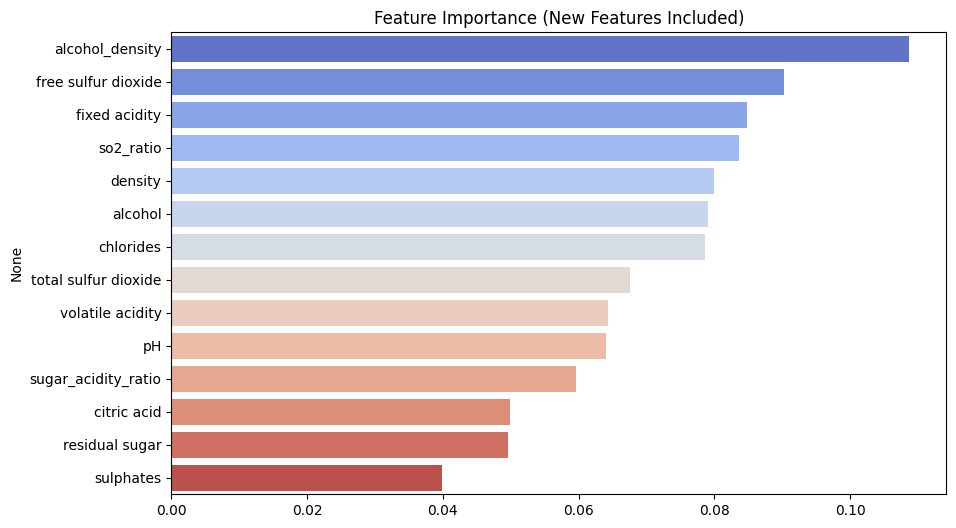

In [7]:
# 5. 새로운 변수가 얼마나 중요한지 확인 (Top 10)
importances_new = rf_model_1.feature_importances_
indices_new = np.argsort(importances_new)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances_new[indices_new], y=X.columns[indices_new], palette="coolwarm")
plt.title("Feature Importance (New Features Included)")
plt.show()

#### SMOTE (No Feature Engineering) + RandomForest

In [8]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

In [9]:
white_wine_df = pd.read_csv('./datasets/winequality-white.csv', sep=';')

df = white_wine_df.copy()

X = df.drop('quality', axis=1)
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

smote = SMOTE(k_neighbors=1, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("=== SMOTE 적용 전 데이터 개수 ===")
print(y_train.value_counts().sort_index())
print("\n=== SMOTE 적용 후 데이터 개수 (모두 똑같이 맞춰짐) ===")
print(y_train_res.value_counts().sort_index())

rf_smote = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42)
rf_smote.fit(X_train_res, y_train_res)

y_pred = rf_smote.predict(X_test)

print(f"\n🔥 SMOTE 적용 후 정확도: {accuracy_score(y_test, y_pred):.2%}")
print("\n=== 상세 성적표 ===")
print(classification_report(y_test, y_pred, zero_division=0))

=== SMOTE 적용 전 데이터 개수 ===
quality
3      15
4     138
5    1166
6    1766
7     688
8     140
9       5
Name: count, dtype: int64

=== SMOTE 적용 후 데이터 개수 (모두 똑같이 맞춰짐) ===
quality
3    1766
4    1766
5    1766
6    1766
7    1766
8    1766
9    1766
Name: count, dtype: int64

🔥 SMOTE 적용 후 정확도: 66.73%

=== 상세 성적표 ===
              precision    recall  f1-score   support

           3       0.50      0.20      0.29         5
           4       0.39      0.48      0.43        25
           5       0.68      0.71      0.70       291
           6       0.71      0.63      0.67       432
           7       0.62      0.75      0.68       192
           8       0.65      0.49      0.56        35

    accuracy                           0.67       980
   macro avg       0.59      0.54      0.55       980
weighted avg       0.67      0.67      0.67       980



#### SMOTE(Feature Engineering) + RandomForest

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from imblearn.over_sampling import SMOTE

# -------------------------------------------------------
# 1. Feature Engineering (모델에게 고급 힌트 주기)
# -------------------------------------------------------
def create_new_features(df):
    df_new = df.copy()
    
    # Feature A: 활성 이산화황 비율 (방부제 효율성)
    df_new['so2_ratio'] = df_new['free sulfur dioxide'] / (df_new['total sulfur dioxide'] + 0.000001)
    
    # Feature B: 당도-산도 밸런스 (맛의 조화)
    df_new['sugar_acidity_ratio'] = df_new['residual sugar'] / (df_new['fixed acidity'] + 0.000001)
    
    # Feature C: 알코올-밀도 관계 (바디감의 척도)
    df_new['alcohol_density'] = df_new['alcohol'] * df_new['density']
    
    return df_new

In [12]:
white_wine_df = pd.read_csv('./datasets/winequality-white.csv', sep=';')

df_white = white_wine_df.copy()

df_engineered = create_new_features(df_white)

X = df_engineered.drop('quality', axis=1)
y = df_engineered['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
smote = SMOTE(k_neighbors=1, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"SMOTE 적용 전 훈련 데이터: {len(y_train)}")
print(f"SMOTE 적용 후 훈련 데이터: {len(y_train_res)}")

SMOTE 적용 전 훈련 데이터: 3918
SMOTE 적용 후 훈련 데이터: 12362


In [14]:
rf_final = RandomForestClassifier(
    n_estimators=300,   # 나무 개수를 좀 더 늘려서(300) 신중하게 판단
    max_depth=20,       # 깊이도 조금 더 깊게 허용
    random_state=42
)
rf_final.fit(X_train_res, y_train_res)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y


🔥 [피처 엔지니어링 + SMOTE] 최종 정확도: 68.47%

=== 상세 성적표 ===
              precision    recall  f1-score   support

           3       0.50      0.20      0.29         5
           4       0.38      0.44      0.41        25
           5       0.71      0.75      0.73       291
           6       0.71      0.67      0.69       432
           7       0.65      0.70      0.67       192
           8       0.63      0.49      0.55        35

    accuracy                           0.68       980
   macro avg       0.60      0.54      0.56       980
weighted avg       0.69      0.68      0.68       980



/tmp/ipykernel_3256/1370140666.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=X.columns[indices], palette="viridis")


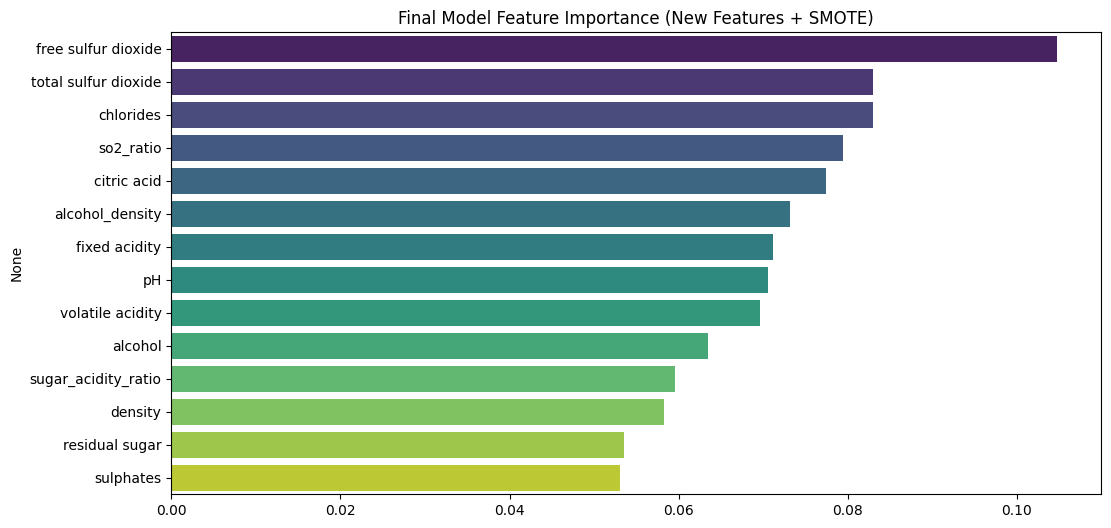

In [15]:
y_pred_final = rf_final.predict(X_test)

print(f"\n🔥 [피처 엔지니어링 + SMOTE] 최종 정확도: {accuracy_score(y_test, y_pred_final):.2%}")
print("\n=== 상세 성적표 ===")
print(classification_report(y_test, y_pred_final, zero_division=0))

# -------------------------------------------------------
# 6. 최종 중요 변수 시각화
# -------------------------------------------------------
importances = rf_final.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
sns.barplot(x=importances[indices], y=X.columns[indices], palette="viridis")
plt.title("Final Model Feature Importance (New Features + SMOTE)")
plt.show()

### Ensemble

#### SMOTE (Feature Engineering) + Ensemble (lightGBM + XGBoost)

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 모델링 라이브러리
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.ensemble import VotingClassifier
from imblearn.over_sampling import SMOTE

# Boosting 모델
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [18]:
white_wine_df = pd.read_csv('./datasets/winequality-white.csv', sep=';')
df_white = white_wine_df.copy()

df_white['so2_ratio'] = df_white['free sulfur dioxide'] / (df_white['total sulfur dioxide'] + 0.000001)
df_white['sugar_acidity_ratio'] = df_white['residual sugar'] / (df_white['fixed acidity'] + 0.000001)
df_white['alcohol_density'] = df_white['alcohol'] * df_white['density']

X = df_white.drop('quality', axis=1)
y = df_white['quality']

In [19]:
# XGBoost/LightGBM은 타겟값이 0부터 시작해야 오류가 안 납니다.
# 예: 품질 3, 4, 5, 6, 7, 8 -> 0, 1, 2, 3, 4, 5 로 변환
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# SMOTE 적용 (k_neighbors=1)
smote = SMOTE(k_neighbors=1, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"SMOTE 적용 후 학습 데이터 크기: {len(y_train_res)}")

SMOTE 적용 후 학습 데이터 크기: 12362


In [21]:
# XGBoost
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=10,
    random_state=42,
    eval_metric='mlogloss'
)

# LightGBM
lgbm_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=10,
    random_state=42,
    verbose=-1 # 경고 메시지 끄기
)

# 5. 앙상블 (Voting Ensemble)
# -------------------------------------------------------
# 두 모델의 예측 확률을 평균 내어 투표하는 방식 (Soft Voting)
voting_model = VotingClassifier(
    estimators=[('xgb', xgb_model), ('lgbm', lgbm_model)],
    voting='soft'
)

# 앙상블 모델 학습
print("앙상블 모델 학습 중... ⏳")
voting_model.fit(X_train_res, y_train_res)

앙상블 모델 학습 중... ⏳


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('xgb', ...), ('lgbm', ...)]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None



🔥 [XGBoost + LightGBM 앙상블] 최종 정확도: 67.76%

=== 상세 성적표 ===
              precision    recall  f1-score   support

           3       0.50      0.20      0.29         5
           4       0.36      0.36      0.36        25
           5       0.71      0.69      0.70       291
           6       0.69      0.74      0.71       432
           7       0.67      0.61      0.64       192
           8       0.55      0.49      0.52        35

    accuracy                           0.68       980
   macro avg       0.58      0.51      0.54       980
weighted avg       0.68      0.68      0.68       980



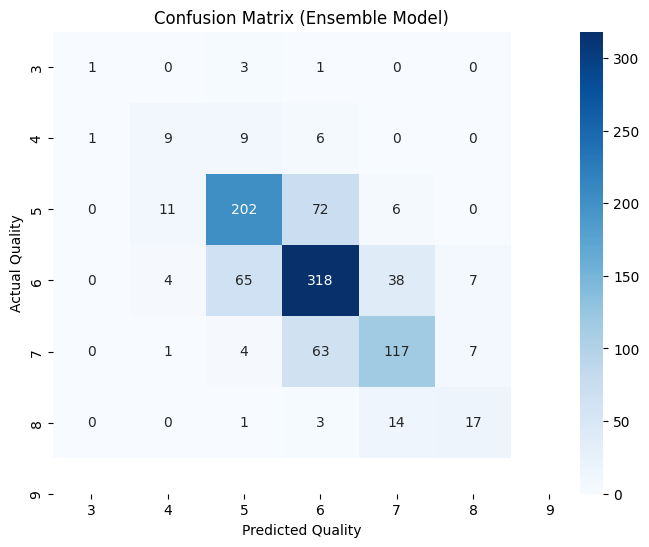

In [22]:
y_pred = voting_model.predict(X_test)

# 인코딩된 라벨을 다시 원래 점수(3~8점)로 복구
y_test_original = le.inverse_transform(y_test)
y_pred_original = le.inverse_transform(y_pred)

print(f"\n🔥 [XGBoost + LightGBM 앙상블] 최종 정확도: {accuracy_score(y_test_original, y_pred_original):.2%}")
print("\n=== 상세 성적표 ===")
print(classification_report(y_test_original, y_pred_original, zero_division=0))

# Confusion Matrix 시각화
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_original, y_pred_original)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix (Ensemble Model)')
plt.xlabel('Predicted Quality')
plt.ylabel('Actual Quality')
plt.show()